# Metrics analysis

Loads the per-combo CSV files produced by [`run_sweep.py --output-dir`](run_sweep.py) and
provides small helpers for statistical comparison of any single metric between a
pair of evaluations (combos).

**Setup** (run once in a venv):

```bash
python3 -m venv .venv
source .venv/bin/activate
pip3 install -r requirements.txt
python3 -m ipykernel install --user --name master-diploma --display-name 'master-diploma (.venv)'
jupyter notebook demo/report.ipynb
```

Each CSV is expected to contain one row per repeated run of a single combo,
with parameter columns plus `rc`, `time_s`, and the scraped metric columns
(`orders`, `conflicts`, `avg_wait`, `avg_reverse`, `avg_speed`, `sim_speed`).
Missing values are represented as the literal `-`.

In [100]:
from __future__ import annotations

import math
from itertools import combinations
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
from cliffs_delta import cliffs_delta

pd.set_option('display.float_format', lambda v: f'{v:.4g}')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Columns considered numeric metrics in the sweep CSVs.
METRIC_COLUMNS = [
    'orders',
    'conflicts',
    'avg_wait',
    'avg_reverse',
    'avg_speed',
    'avg_order_time',
]

## Loading

In [101]:
def load_run(csv_path: str | Path) -> pd.DataFrame | None:
    """Load a single per-combo CSV produced by run_sweep.py.

    Returns a DataFrame in which the known metric columns are numeric
    (with the literal '-' coerced to NaN). All other columns are left as is.
    """
    df = pd.read_csv(csv_path, dtype=str, keep_default_na=False)
    if df.size == 0:
        return None
    for col in METRIC_COLUMNS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col].replace('-', np.nan), errors='coerce')
    return df


def load_runs(directory: str | Path, pattern: str = '*.csv') -> dict[str, pd.DataFrame]:
    """Load every CSV from `directory` into a dict keyed by file stem.

    The stem is the filename without the .csv extension. By default
    run_sweep.py names CSVs after a sanitized combo string, e.g.
    `router=astar_agents=10.csv`, so the keys end up being human-readable
    combo labels.
    """
    directory = Path(directory)
    runs: dict[str, pd.DataFrame] = {}
    for path in sorted(directory.glob(pattern)):
        data = load_run(path)
        if data is not None:
            runs[path.stem] = data
    return runs


def overview(runs: dict[str, pd.DataFrame], metric: str) -> pd.DataFrame:
    """Compact mean/std/n table across all loaded runs for a single metric."""
    rows = []
    for label, df in runs.items():
        if metric not in df.columns:
            continue
        series = df[metric].dropna()
        rows.append({
            'combo': label,
            'n': int(series.size),
            'mean': series.mean() if series.size else np.nan,
            'std': series.std(ddof=1) if series.size > 1 else np.nan,
            'min': series.min() if series.size else np.nan,
            'max': series.max() if series.size else np.nan,
        })
    return pd.DataFrame(rows).set_index('combo')

## Statistical comparison of conflict-resolution methods

Each combo (CSV) is an independent sample of one method: every row is a separate
simulation run with its own seed. Sample sizes are large (n ≥ 10³), and the metrics
of interest (`orders`, `avg_speed`, `avg_wait`) are not normally distributed:

- `orders` is an integer count,
- `avg_speed` / `avg_wait` are agent-averaged but still have heavy right tails caused by
  occasional congestion (see e.g. the 1.089 spike among ~0.17 values in `time_s`).

We therefore use a **minimal non-parametric toolkit** rather than t-tests/ANOVA:

1. **Mann–Whitney U-test** — statistical significance of the difference between two
   methods. Assumes only independence of observations and makes no normality
   assumption; robust to the heavy tails above.
2. **Cliff's delta** — non-parametric effect size in `[-1, 1]`, derived from the same
   ranks as the U statistic. At our sample sizes any non-zero difference becomes
   "statistically significant" (p → 0), so a *size* of effect is mandatory to judge
   practical relevance. Standard thresholds (Romano et al., 2006): `|δ| < 0.147`
   negligible, `< 0.33` small, `< 0.474` medium, `≥ 0.474` large.
3. **Holm correction** — when comparing k methods pairwise we run k·(k−1)/2 tests
   per metric; Holm controls the family-wise error rate without sacrificing power
   like plain Bonferroni would.

Parametric checks (Shapiro–Wilk, Levene, Welch's t-test, ANOVA, bootstrap CI) are
intentionally omitted: with non-normal data and large n they would either reject
trivially (assumption tests) or merely duplicate the U-test result.

In [102]:
def _delta_magnitude(delta: float) -> str:
    ad = abs(delta)
    if ad < 0.147:
        return 'negligible'
    if ad < 0.33:
        return 'small'
    if ad < 0.474:
        return 'medium'
    return 'large'


def compare_pair(runs: dict[str, pd.DataFrame],
                 combo_a: str, combo_b: str, metric: str) -> pd.Series:
    """Mann-Whitney U + Cliff's delta for one (combo_a, combo_b, metric) triple."""
    a = runs[combo_a][metric].dropna().to_numpy()
    b = runs[combo_b][metric].dropna().to_numpy()
    u_stat, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    delta = cliffs_delta(a, b)[0]
    return pd.Series({
        'metric': metric,
        'a': combo_a,
        'b': combo_b,
        'n_a': int(a.size),
        'n_b': int(b.size),
        'median_a': float(np.median(a)),
        'median_b': float(np.median(b)),
        'mwu_U': float(u_stat),
        'p_value': float(p),
        'cliffs_delta': float(delta),
        'effect': _delta_magnitude(delta),
    })


def compare_pairs(pairs: Iterable[tuple[str, str]],
                  runs: dict[str, pd.DataFrame],
                  metric: str,
                  alpha: float = 0.05) -> pd.DataFrame:
    """Run compare_pair over every pair in `pairs`.
    
    The resulting table includes Holm-adjusted p-values and a boolean
    `significant` flag at level `alpha`.
    """
    rows = [compare_pair(runs, a, b, metric) for a, b in pairs]
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    reject, p_adj, *_ = multipletests(out['p_value'].fillna(1.0),
                                      alpha=alpha, method='holm')
    out['p_holm'] = p_adj
    out['significant'] = reject
    return out.sort_values('p_holm').reset_index(drop=True)


def compare_all_pairs(runs: dict[str, pd.DataFrame],
                      metric: str,
                      alpha: float = 0.05) -> pd.DataFrame:
    """Run compare_pair over every unordered pair of combos for one metric.

    The resulting table includes Holm-adjusted p-values and a boolean
    `significant` flag at level `alpha`.
    """
    return compare_pairs(combinations(list(runs.keys()), 2), runs, metric, alpha)

### How to read the table

- `p_holm < 0.05` **and** `|cliffs_delta| ≥ 0.147` → methods differ both
  statistically and practically.
- `p_holm < 0.05` but `effect = negligible` → the difference is only an
  artefact of large n; ignore in practice.
- `p_holm ≥ 0.05` → no detectable difference for this metric.

## Plan execution (per `statistical-significance-report.md`)

The cells below apply the analysis plan to the bundled `reports/` data:

- **§3.1** for each `resolver` in each stratum `(graph, agents)` pick the
  best router (`astar` vs `stat`) by majority vote on 3 metrics with Holm
  correction (K=3);
- **§3.2** compare `reverse` vs `semaphore` in their best-router
  configurations per stratum (15 strata);
- **§3.3** compare `ccbs+none` (offline reference) against the best
  lifelong configurations for `agents ∈ {10, 100, 1000}` (9 strata,
  Holm family of K=6 per stratum);
- **§5** plot `metric(agents)` curves per `(graph, router, resolver)`.

`astar+none` (no resolver, upper-bound run) is excluded from all
pairwise comparisons by construction.

In [103]:
import re
from collections import defaultdict

PRIMARY_METRICS = ['orders', 'avg_order_time', 'avg_speed']
HIGHER_IS_BETTER = {'orders': True, 'avg_order_time': False, 'avg_speed': True}
GRAPH_ORDER = ['small', 'medium', 'large']
AGENTS_ORDER = [10, 100, 500, 1000, 5000]
CCBS_AGENTS = [10, 100, 1000]


def parse_combo(name: str) -> dict:
    """Parse a combo filename stem into a dict of factor levels.

    Tolerates underscores inside values (e.g. graph=maps_small_map.geojson)
    by reconstructing values until the next `key=` token is met.
    """
    parts = name.split('_')
    result: dict = {}
    cur_key, cur_val = None, []
    for p in parts:
        if '=' in p and re.match(r'^[A-Za-z_]+=', p):
            if cur_key is not None:
                result[cur_key] = '_'.join(cur_val)
            k, v = p.split('=', 1)
            cur_key, cur_val = k, [v]
        else:
            cur_val.append(p)
    if cur_key is not None:
        result[cur_key] = '_'.join(cur_val)
    g = result.get('graph', '')
    for short in GRAPH_ORDER:
        if short in g:
            result['graph'] = short
            break
    if 'agents' in result:
        result['agents'] = int(result['agents'])
    return result


def select(runs: dict[str, pd.DataFrame], **filters) -> dict[str, pd.DataFrame]:
    """Return the sub-dict of runs whose parsed combo matches all filters."""
    out = {}
    for name, df in runs.items():
        meta = parse_combo(name)
        if all(meta.get(k) == v for k, v in filters.items()):
            out[name] = df
    return out


def find_combo(runs: dict[str, pd.DataFrame], **filters) -> str | None:
    """Return the single combo name matching the filter, or None."""
    sub = select(runs, **filters)
    if not sub:
        return None
    if len(sub) > 1:
        raise ValueError(f'Ambiguous filter {filters}: {list(sub)}')
    return next(iter(sub))


# Reload to make sure runs reflects current reports/ contents.
runs = load_runs('reports')

# Exclude astar+none — used only as an upper-bound narrative reference.
runs_active = {n: df for n, df in runs.items()
               if not (parse_combo(n).get('router') == 'astar'
                       and parse_combo(n).get('resolver') == 'none')}
print(f'loaded {len(runs)} combos, {len(runs_active)} active after excluding astar+none')
pd.DataFrame([parse_combo(n) for n in sorted(runs_active)]).groupby(
    ['resolver', 'router']).size().rename('n_strata')

loaded 77 combos, 68 active after excluding astar+none


/tmp/ipykernel_22137/2362830274.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = pd.to_numeric(df[col].replace('-', np.nan), errors='coerce')
/tmp/ipykernel_22137/2362830274.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = pd.to_numeric(df[col].replace('-', np.nan), errors='coerce')
/tmp/ipykernel_22137/2362830274.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. T

resolver   router
none       ccbs       8
reverse    astar     15
           stat      15
semaphore  astar     15
           stat      15
Name: n_strata, dtype: int64

### §3.1 Per-resolver winner router

Within each stratum `(graph, agents)` and for each resolver
`R ∈ {reverse, semaphore}` compare `astar+R` vs `stat+R` on the three
primary metrics. Holm correction over K=3 per row. Voting rule:

- per metric: `negligible` if `p_holm ≥ 0.05` or `|δ| < 0.147`;
  otherwise the combo with the better median (per metric direction);
- winner: ≥ 2 of 3 votes; 1-1-1 split → priority to `orders` (main KPI);
- all three negligible → `both` (§3.2 will expand to a Cartesian product).

In [104]:
def _vote_winner(row, a_label, b_label) -> str:
    """Decide per-metric winner from a compare_pair row + Holm."""
    if not row['significant'] or row['effect'] == 'negligible':
        return 'tie'
    higher_better = HIGHER_IS_BETTER[row['metric']]
    a_better = row['cliffs_delta'] > 0 if higher_better else row['cliffs_delta'] < 0
    return a_label if a_better else b_label


def _resolve_votes(votes_by_metric: dict[str, str], a_label, b_label) -> str:
    counts = {a_label: 0, b_label: 0, 'tie': 0}
    for v in votes_by_metric.values():
        counts[v] += 1
    if counts['tie'] == 3:
        return 'both'
    if counts[a_label] >= 2:
        return a_label
    if counts[b_label] >= 2:
        return b_label
    # 1-1-1 split: priority to orders.
    return votes_by_metric.get('orders', 'both')


def compare_routers_for_resolver(runs, graph, agents, resolver):
    a_name = find_combo(runs, graph=graph, agents=agents, resolver=resolver, router='astar')
    b_name = find_combo(runs, graph=graph, agents=agents, resolver=resolver, router='stat')
    if a_name is None or b_name is None:
        return None, None
    pairs = [(a_name, b_name)] * len(PRIMARY_METRICS)
    tables = [compare_pairs([(a_name, b_name)], runs, m) for m in PRIMARY_METRICS]
    # We need joint Holm across the 3 metrics, so reuse multipletests directly.
    raw_rows = [compare_pair(runs, a_name, b_name, m) for m in PRIMARY_METRICS]
    raw = pd.DataFrame(raw_rows)
    reject, p_adj, *_ = multipletests(raw['p_value'].fillna(1.0), alpha=0.05, method='holm')
    raw['p_holm'] = p_adj
    raw['significant'] = reject
    raw['graph'] = graph
    raw['agents'] = agents
    raw['resolver'] = resolver
    raw['vote'] = raw.apply(lambda r: _vote_winner(r, 'astar', 'stat'), axis=1)
    winner = _resolve_votes(dict(zip(raw['metric'], raw['vote'])), 'astar', 'stat')
    return raw, winner

In [105]:
rows_31 = []
winner_router: dict[tuple[str, str, int], str] = {}
for resolver in ('reverse', 'semaphore'):
    for graph in GRAPH_ORDER:
        for agents in AGENTS_ORDER:
            tbl, winner = compare_routers_for_resolver(runs_active, graph, agents, resolver)
            if tbl is None:
                continue
            rows_31.append(tbl)
            winner_router[(resolver, graph, agents)] = winner

table_31 = pd.concat(rows_31, ignore_index=True)[
    ['resolver', 'graph', 'agents', 'metric',
     'median_a', 'median_b', 'cliffs_delta', 'effect',
     'p_holm', 'significant', 'vote']
]

display(table_31)

,resolver,graph,agents,metric,median_a,median_b,cliffs_delta,effect,p_holm,significant,vote
0,reverse,small,10,orders,2013,2013,-0.01293,negligible,1,False,tie
1,reverse,small,10,avg_order_time,107.3,107.3,0.01165,negligible,1,False,tie
2,reverse,small,10,avg_speed,2.063,2.067,-0.7605,large,4.7e-39,True,stat
3,reverse,small,100,orders,1.789e+04,1.841e+04,-1,large,3.113e-29,True,stat
4,reverse,small,100,avg_order_time,120.7,117.3,1,large,3.113e-29,True,stat
5,reverse,small,100,avg_speed,1.934,1.988,-1,large,3.113e-29,True,stat
6,reverse,small,500,orders,5.036e+04,7.234e+04,-1,large,1.245e-05,True,stat
7,reverse,small,500,avg_order_time,212.9,149.2,1,large,1.245e-05,True,stat
8,reverse,small,500,avg_speed,1.635,1.936,-1,large,1.245e-05,True,stat
9,reverse,small,1000,orders,5.384e+04,1.282e+05,-1,large,5.331e-05,True,stat


In [106]:
# Winner-router summary matrix per resolver: rows = graph, cols = agents.
def winner_router_matrix(resolver):
    m = pd.DataFrame(index=GRAPH_ORDER, columns=AGENTS_ORDER, dtype=object)
    for (r, g, a), w in winner_router.items():
        if r == resolver:
            m.loc[g, a] = w
    return m

for resolver in ('reverse', 'semaphore'):
    print(f'\nwinner_router[{resolver}]:')
    display(winner_router_matrix(resolver))


winner_router[reverse]:


,10,100,500,1000,5000
small,tie,stat,stat,stat,both
medium,tie,stat,stat,both,both
large,tie,stat,stat,both,both



winner_router[semaphore]:


,10,100,500,1000,5000
small,tie,stat,stat,stat,both
medium,tie,stat,stat,stat,both
large,tie,stat,stat,stat,both


### §3.2 `reverse` vs `semaphore` in best-router configurations

Per stratum take the winner router from §3.1 for each resolver and run
a single pair `(astar|stat)+reverse` vs `(astar|stat)+semaphore`. When
§3.1 returns `both` for a resolver the pair is expanded to the Cartesian
product (1, 2 or 4 pairs per stratum); all pairs of a stratum share one
Holm family of size `3 · #pairs`.

In [107]:
def _routers_for(resolver, graph, agents):
    w = winner_router.get((resolver, graph, agents))
    if w == 'both':
        return ['astar', 'stat']
    return [w] if w else []


rows_32 = []
summary_32 = []  # one row per stratum: orders winner + |delta|
for graph in GRAPH_ORDER:
    for agents in AGENTS_ORDER:
        rev_routers = _routers_for('reverse', graph, agents)
        sem_routers = _routers_for('semaphore', graph, agents)
        if not rev_routers or not sem_routers:
            continue
        stratum_rows = []
        for r_router in rev_routers:
            for s_router in sem_routers:
                a_name = find_combo(runs_active, graph=graph, agents=agents,
                                    resolver='reverse', router=r_router)
                b_name = find_combo(runs_active, graph=graph, agents=agents,
                                    resolver='semaphore', router=s_router)
                if not a_name or not b_name:
                    continue
                for m in PRIMARY_METRICS:
                    s = compare_pair(runs_active, a_name, b_name, m)
                    s['graph'] = graph
                    s['agents'] = agents
                    s['router_reverse'] = r_router
                    s['router_semaphore'] = s_router
                    stratum_rows.append(s)
        if not stratum_rows:
            continue
        df = pd.DataFrame(stratum_rows)
        reject, p_adj, *_ = multipletests(df['p_value'].fillna(1.0),
                                          alpha=0.05, method='holm')
        df['p_holm'] = p_adj
        df['significant'] = reject
        df['vote'] = df.apply(lambda r: _vote_winner(r, 'reverse', 'semaphore'), axis=1)
        rows_32.append(df)
        # Stratum summary: MAJORITY VOTE across ALL primary metrics.
        # Each (metric, expanded-pair) cell contributes one vote.
        votes = df['vote'].tolist()
        counts = {'reverse': votes.count('reverse'),
                  'semaphore': votes.count('semaphore'),
                  'tie': votes.count('tie')}
        if counts['reverse'] > counts['semaphore'] and counts['reverse'] > counts['tie']:
            winner = 'reverse'
        elif counts['semaphore'] > counts['reverse'] and counts['semaphore'] > counts['tie']:
            winner = 'semaphore'
        elif counts['reverse'] == counts['semaphore'] and counts['reverse'] > 0:
            winner = 'mixed'
        else:
            winner = 'tie'
        summary_32.append({
            'graph': graph, 'agents': agents,
            'winner': winner,
            'votes_reverse': counts['reverse'],
            'votes_semaphore': counts['semaphore'],
            'votes_tie': counts['tie'],
            'votes_total': len(votes),
            'abs_delta_median': float(df['cliffs_delta'].abs().median()),
            'n_pairs': int(len(df[df['metric'] == 'orders'])),
        })

table_32 = pd.concat(rows_32, ignore_index=True)[
    ['graph', 'agents', 'router_reverse', 'router_semaphore', 'metric',
     'median_a', 'median_b', 'cliffs_delta', 'effect',
     'p_holm', 'significant', 'vote']
]
table_32

,graph,agents,router_reverse,router_semaphore,metric,median_a,median_b,cliffs_delta,effect,p_holm,significant,vote
0,small,100,stat,stat,orders,1.841e+04,1.853e+04,-0.8455,large,4.638e-21,True,semaphore
1,small,100,stat,stat,avg_order_time,117.3,116.5,0.8381,large,5.153e-21,True,semaphore
2,small,100,stat,stat,avg_speed,1.988,1.958,1,large,9.39e-29,True,reverse
3,small,500,stat,stat,orders,7.234e+04,6.152e+04,1,large,1.245e-05,True,reverse
4,small,500,stat,stat,avg_order_time,149.2,175.3,-1,large,1.245e-05,True,reverse
5,small,500,stat,stat,avg_speed,1.936,1.811,1,large,1.245e-05,True,reverse
6,small,1000,stat,stat,orders,1.282e+05,8.897e+04,1,large,8.368e-05,True,reverse
7,small,1000,stat,stat,avg_order_time,168.4,242.5,-1,large,8.368e-05,True,reverse
8,small,1000,stat,stat,avg_speed,1.924,1.788,1,large,8.368e-05,True,reverse
9,small,5000,astar,astar,orders,1.177e+05,7.799e+04,1,large,1,False,tie


In [108]:
# Main artefact: 3x5 matrix (graph x agents) — majority-vote winner + |delta|.
summary_32_df = pd.DataFrame(summary_32)
winner_matrix = summary_32_df.pivot(index='graph', columns='agents',
                                    values='winner').reindex(
    index=GRAPH_ORDER, columns=AGENTS_ORDER)
delta_matrix = summary_32_df.pivot(index='graph', columns='agents',
                                   values='abs_delta_median').reindex(
    index=GRAPH_ORDER, columns=AGENTS_ORDER)
print('stratum winner (majority vote across all primary metrics):')
display(winner_matrix)
print('|cliffs delta| median over all metrics x expanded pairs:')
display(delta_matrix.round(3))
print('per-stratum vote breakdown:')
display(summary_32_df.set_index(['graph', 'agents']))

stratum winner (majority vote across all primary metrics):


agents,10,100,500,1000,5000
graph,,,,,
small,NaN,semaphore,reverse,reverse,tie
medium,NaN,semaphore,semaphore,mixed,tie
large,NaN,semaphore,semaphore,tie,tie


|cliffs delta| median over all metrics x expanded pairs:


agents,10,100,500,1000,5000
graph,,,,,
small,NaN,0.846,1,1,1
medium,NaN,0.95,1,1,1
large,NaN,0.437,1,1,1


per-stratum vote breakdown:


winner  votes_reverse  votes_semaphore  votes_tie  \
graph  agents                                                         
small  100     semaphore              1                2          0   
       500       reverse              3                0          0   
       1000      reverse              3                0          0   
       5000          tie              0                0         12   
medium 100     semaphore              0                3          0   
       500     semaphore              1                2          0   
       1000        mixed              3                3          0   
       5000          tie              0                0         12   
large  100     semaphore              0                3          0   
       500     semaphore              1                2          0   
       1000          tie              0                0          6   
       5000          tie              0                0         12   

               votes_total  abs_delta_median  n_pairs  
graph  agents                                          
small  100               3            0.8455        1  
       500               3                 1        1  
       1000              3                 1        1  
       5000             12                 1        4  
medium 100               3              0.95        1  
       500               3                 1        1  
       1000              6                 1        2  
       5000             12                 1        4  
large  100               3            0.4373        1  
       500               3                 1        1  
       1000              6                 1        2  
       5000             12                 1        4

### §3.3 `ccbs+none` vs best lifelong configurations

Restricted to `agents ∈ {10, 100, 1000}`. Per stratum two pairs
(`ccbs` vs best-reverse, `ccbs` vs best-semaphore) × three primary
metrics, all six tests in one Holm family. `avg_wait` is reported as a
qualitative side comment without Holm.

In [109]:
rows_33 = []
wait_rows_33 = []
for graph in GRAPH_ORDER:
    for agents in CCBS_AGENTS:
        ccbs = find_combo(runs, graph=graph, agents=agents,
                          router='ccbs', resolver='none')
        if not ccbs:
            continue
        stratum_rows = []
        for resolver in ('reverse', 'semaphore'):
            for r in _routers_for(resolver, graph, agents):
                cand = find_combo(runs_active, graph=graph, agents=agents,
                                  resolver=resolver, router=r)
                if not cand:
                    continue
                for m in PRIMARY_METRICS:
                    # print(agents, resolver, r, m)
                    s = compare_pair(runs, ccbs, cand, m)
                    s['graph'] = graph
                    s['agents'] = agents
                    s['candidate_resolver'] = resolver
                    s['candidate_router'] = r
                    stratum_rows.append(s)
        if not stratum_rows:
            continue
        df = pd.DataFrame(stratum_rows)
        reject, p_adj, *_ = multipletests(df['p_value'].fillna(1.0),
                                          alpha=0.05, method='holm')
        df['p_holm'] = p_adj
        df['significant'] = reject
        df['vote'] = df.apply(lambda r: _vote_winner(r, 'ccbs', 'lifelong'), axis=1)
        rows_33.append(df)

table_33 = pd.concat(rows_33, ignore_index=True)[
    ['graph', 'agents', 'candidate_resolver', 'candidate_router', 'metric',
     'median_a', 'median_b', 'cliffs_delta', 'effect',
     'p_holm', 'significant', 'vote']
]
table_33

,graph,agents,candidate_resolver,candidate_router,metric,median_a,median_b,cliffs_delta,effect,p_holm,significant,vote
0,small,100,reverse,stat,orders,1.495e+04,1.841e+04,-1,large,2.042e-29,True,lifelong
1,small,100,reverse,stat,avg_order_time,144.4,117.3,1,large,2.042e-29,True,lifelong
2,small,100,reverse,stat,avg_speed,1.834,1.988,-1,large,2.042e-29,True,lifelong
3,small,100,semaphore,stat,orders,1.495e+04,1.853e+04,-1,large,2.042e-29,True,lifelong
4,small,100,semaphore,stat,avg_order_time,144.4,116.5,1,large,2.042e-29,True,lifelong
5,small,100,semaphore,stat,avg_speed,1.834,1.958,-1,large,2.042e-29,True,lifelong
6,small,1000,reverse,stat,orders,7.606e+04,1.282e+05,-1,large,0.0001371,True,lifelong
7,small,1000,reverse,stat,avg_order_time,283.9,168.4,1,large,0.0001371,True,lifelong
8,small,1000,reverse,stat,avg_speed,1.365,1.924,-1,large,0.0001371,True,lifelong
9,small,1000,semaphore,stat,orders,7.606e+04,8.897e+04,-1,large,1.632e-05,True,lifelong


### Overall summary across strata

Aggregates the per-stratum results from §3.1–§3.3 into a single view:

- §3.1 — how often each router wins per resolver across the 15 strata;
- §3.2 — global tally of stratum winners + per-metric vote totals;
- §3.3 — how often `ccbs` beats each lifelong candidate per metric.

In [110]:
# §3.1 overall: per resolver, how often each router is selected.
rows = []
for resolver in ('reverse', 'semaphore'):
    counts = defaultdict(int)
    for (r, _g, _a), w in winner_router.items():
        if r == resolver:
            counts[w] += 1
    rows.append({'resolver': resolver, **counts,
                 'total': sum(counts.values())})
summary_31_overall = pd.DataFrame(rows).fillna(0).set_index('resolver')
print('§3.1 router selection counts across 15 strata:')
display(summary_31_overall)

§3.1 router selection counts across 15 strata:


,tie,stat,both,total
resolver,,,,
reverse,3,7,5,15
semaphore,3,9,3,15


In [111]:
# §3.2 overall: stratum winner tally + per-metric vote tally.
global_winner_tally = summary_32_df['winner'].value_counts().to_frame('strata')
print('§3.2 stratum winners (majority vote across metrics, 15 strata):')
display(global_winner_tally)

# Per-metric vote breakdown across all strata x expanded pairs.
all_32 = pd.concat(rows_32, ignore_index=True)
per_metric_votes = (all_32.groupby('metric')['vote']
                          .value_counts().unstack(fill_value=0)
                          .reindex(index=PRIMARY_METRICS))
print('§3.2 per-metric vote counts (each row = one metric over all stratum x pair tests):')
display(per_metric_votes)

# Per-metric median |cliffs delta| (effect strength).
effect_by_metric = (all_32.assign(abs_d=all_32['cliffs_delta'].abs())
                          .groupby('metric')['abs_d'].median()
                          .reindex(PRIMARY_METRICS)
                          .to_frame('median_|delta|'))
display(effect_by_metric.round(3))

§3.2 stratum winners (majority vote across metrics, 15 strata):


,strata
winner,
semaphore,5
tie,4
reverse,2
mixed,1


§3.2 per-metric vote counts (each row = one metric over all stratum x pair tests):


vote,reverse,semaphore,tie
metric,,,
orders,3,6,14
avg_order_time,3,6,14
avg_speed,6,3,14


,median_|delta|
metric,
orders,1
avg_order_time,1
avg_speed,1


In [112]:
# §3.3 overall: how often ccbs wins / loses / ties per metric x candidate.
all_33 = pd.concat(rows_33, ignore_index=True) if rows_33 else pd.DataFrame()
if not all_33.empty:
    overview_33 = (all_33.groupby(['candidate_resolver', 'metric'])['vote']
                         .value_counts().unstack(fill_value=0))
    print('§3.3 ccbs-vs-lifelong votes across 9 strata (ccbs wins / lifelong wins / tie):')
    display(overview_33)
else:
    print('§3.3 has no rows (ccbs data missing).')

§3.3 ccbs-vs-lifelong votes across 9 strata (ccbs wins / lifelong wins / tie):


vote                               ccbs  lifelong  tie
candidate_resolver metric                             
reverse            avg_order_time     1         2    3
                   avg_speed          1         3    2
                   orders             1         2    3
semaphore          avg_order_time     1         3    1
                   avg_speed          1         3    1
                   orders             1         2    2

In [113]:
# Final one-line verdict for the resolver comparison (§3.2).
tally = summary_32_df['winner'].value_counts()
n = int(tally.sum())
rev = int(tally.get('reverse', 0))
sem = int(tally.get('semaphore', 0))
mix = int(tally.get('mixed', 0))
tie = int(tally.get('tie', 0))
if rev > sem and rev > mix + tie:
    verdict = f'reverse dominates ({rev}/{n} strata)'
elif sem > rev and sem > mix + tie:
    verdict = f'semaphore dominates ({sem}/{n} strata)'
else:
    verdict = (f'no global winner: reverse={rev}, semaphore={sem}, '
               f'mixed={mix}, tie={tie} over {n} strata')
print('GLOBAL VERDICT (§3.2 majority vote):', verdict)

GLOBAL VERDICT (§3.2 majority vote): no global winner: reverse=2, semaphore=5, mixed=1, tie=4 over 12 strata


### §5 metric(agents) curves

For each `(graph, metric)` plot one curve per `(router, resolver)` over
the available `agents` levels. Solid line — median, shaded band — IQR.

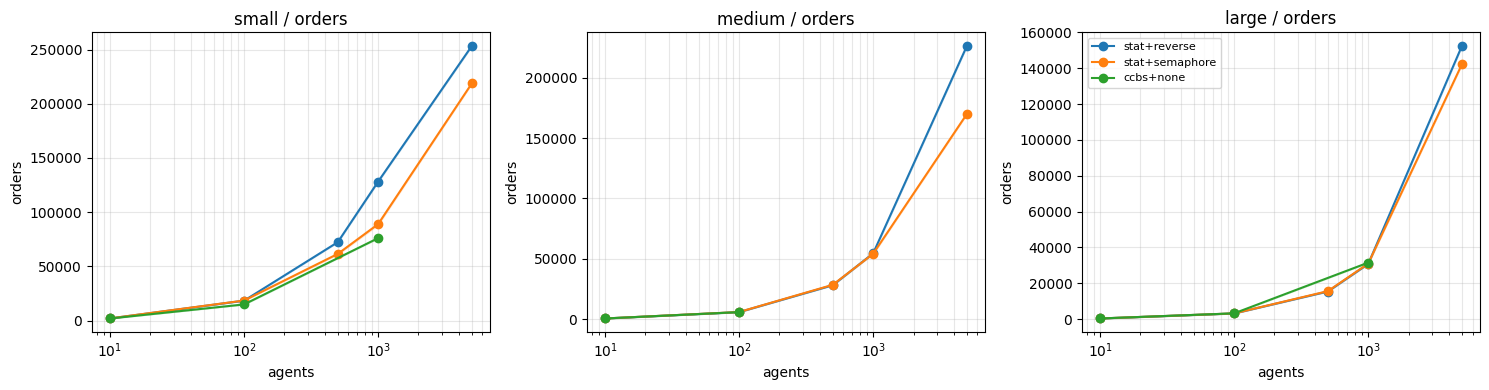

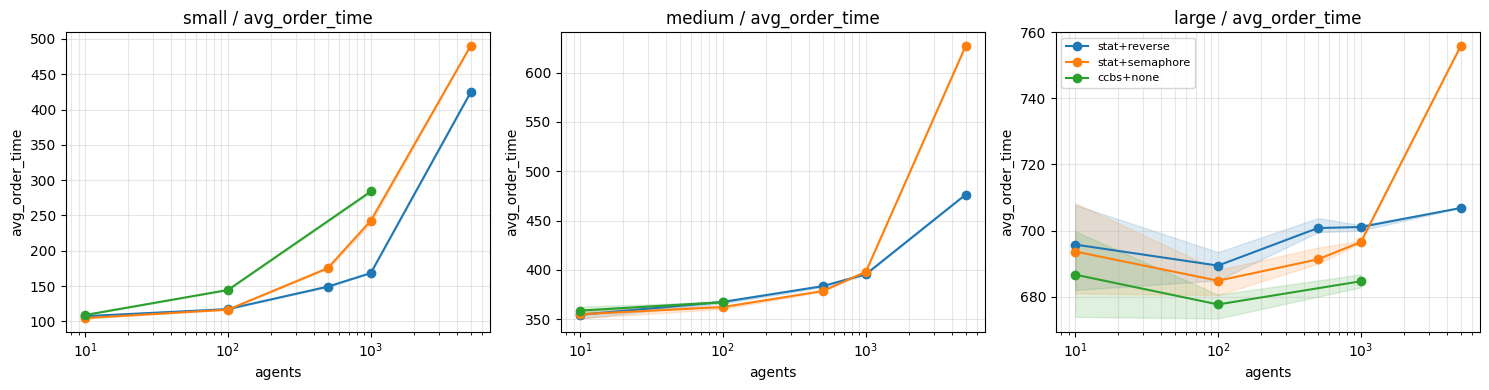

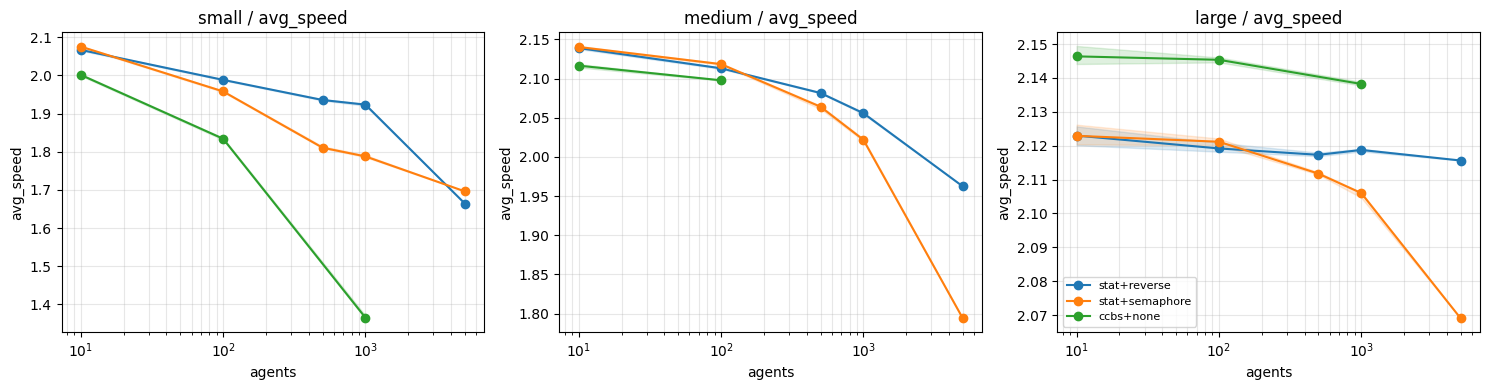

In [114]:
import matplotlib.pyplot as plt


def _curve_data(runs, graph, router, resolver, metric):
    pts = []
    for n_agents in sorted(AGENTS_ORDER + [a for a in CCBS_AGENTS if a not in AGENTS_ORDER]):
        name = find_combo(runs, graph=graph, agents=n_agents,
                          router=router, resolver=resolver)
        if not name or metric not in runs[name].columns:
            continue
        s = runs[name][metric].dropna()
        if s.empty:
            continue
        pts.append((n_agents, s.quantile(0.25), s.median(), s.quantile(0.75)))
    if not pts:
        return None
    arr = np.array(pts)
    return arr[:, 0], arr[:, 1], arr[:, 2], arr[:, 3]


CURVE_CONFIGS = [
    # ('astar', 'reverse'),
    # ('astar', 'semaphore'),
    ('stat', 'reverse'),
    ('stat', 'semaphore'),
    ('ccbs', 'none'),
]

for metric in PRIMARY_METRICS:
    fig, axes = plt.subplots(1, len(GRAPH_ORDER), figsize=(5 * len(GRAPH_ORDER), 4),
                              sharey=False)
    for ax, graph in zip(axes, GRAPH_ORDER):
        for router, resolver in CURVE_CONFIGS:
            data = _curve_data(runs, graph, router, resolver, metric)
            if data is None:
                continue
            xs, q25, med, q75 = data
            label = f'{router}+{resolver}'
            line, = ax.plot(xs, med, marker='o', label=label)
            ax.fill_between(xs, q25, q75, alpha=0.15, color=line.get_color())
        ax.set_xscale('log')
        ax.set_title(f'{graph} / {metric}')
        ax.set_xlabel('agents')
        ax.set_ylabel(metric)
        ax.grid(True, which='both', alpha=0.3)
    axes[-1].legend(loc='best', fontsize=8)
    fig.tight_layout()
    plt.show()